### Step 1: Import Libraries
Load `pandas`/`numpy`, plotting libraries, and `spearmanr` from `scipy.stats` for rank correlation.

In [70]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

### Step 2: Load Dataset
Read the smartphone dataset from `Dataset.xlsx`.

In [ ]:
df = pd.read_excel('Dataset.xlsx')

### Step 3: Descriptive Statistics
Summarize `Rating` and `Reviews` columns.

In [72]:
df[["Rating", "Reviews"]].describe()

,Rating,Reviews
count,5627.000000,5627.000000
mean,4.293940,2338.963924
std,0.210337,5514.820532
min,2.300000,0.000000
25%,4.200000,78.000000
50%,4.300000,380.000000
75%,4.400000,2189.000000
max,4.800000,80982.000000


### Step 4: Correlation Matrix (Pearson)
Compute the default pairwise Pearson correlation between `Rating` and `Reviews`.

In [73]:
df[["Rating", "Reviews"]].corr()

,Rating,Reviews
Rating,1.000000,0.119895
Reviews,0.119895,1.000000


### Step 5: Scatter Plot — Rating vs Reviews
Visualize the relationship between rating and review count.

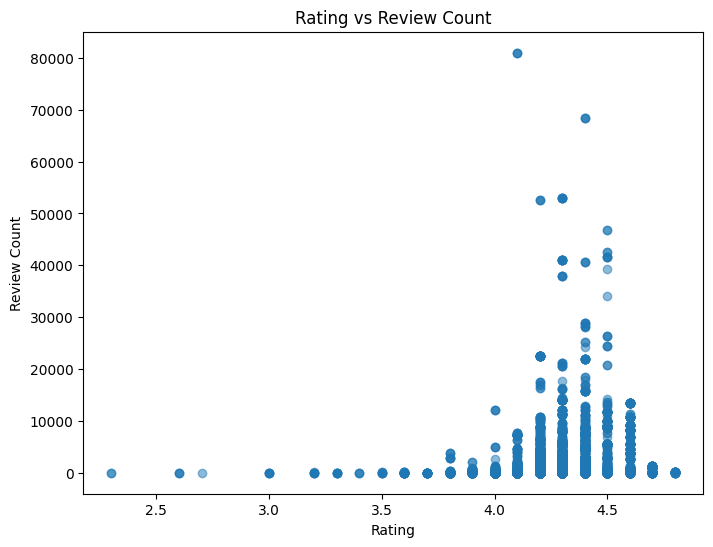

In [74]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Rating"],
    df["Reviews"],
    alpha=0.5
)

plt.xlabel("Rating")
plt.ylabel("Review Count")
plt.title("Rating vs Review Count")

plt.show()

### Step 6: Spearman Correlation Test
Run a Spearman rank correlation test (more robust to skewed/non-linear data than Pearson) between `Rating` and `Reviews`; print the correlation coefficient and p-value.

In [75]:
corr, p_value = spearmanr(
    df["Rating"],
    df["Reviews"]
)

print("Spearman Correlation:", corr)
print("P-value:", p_value)

Spearman Correlation: 0.21898080244227625
P-value: 4.593849271596037e-62


### Business Problem
Do smartphones with higher customer ratings receive more customer reviews?

### Hypotheses
**H₀:** There is no significant relationship between smartphone ratings and review counts.  
**H₁:** There is a significant relationship between smartphone ratings and review counts.

### Statistical Test
Spearman Rank Correlation (robust to skewed data and outliers)

### Results
| Metric | Value |
|--------|-------|
| Spearman Correlation (ρ) | 0.2189 |
| Pearson Correlation | 0.1207 |
| p-value | 4.59 × 10⁻⁶² |

| Variable | Mean | Median | Std Dev |
|----------|------|--------|---------|
| Rating | 4.290 | 4.3 | 0.221 |
| Reviews | 2,338 | 369 | 5,514 |

### Decision
Since p-value (4.59 × 10⁻⁶²) < α (0.05), **reject the null hypothesis.**

### Business Insight
A statistically significant but weak positive relationship was found between ratings and review counts (ρ = 0.2237, p < 0.001). Higher-rated smartphones tend to receive slightly more reviews, but the relationship is modest. The Spearman correlation (0.2237) is stronger than Pearson (0.1207), indicating the association is better described as monotonic rather than strictly linear. This suggests that while customer ratings contribute to product popularity, review counts are heavily influenced by other factors such as brand reputation, product age, pricing, marketing, and sales volume. Ratings alone are not a strong predictor of how many reviews a product will receive.